In [17]:
import sys
print(sys.executable)

c:\Users\PREM KUMAR PRINCE\Desktop\Build For Good\.venv\Scripts\python.exe


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv('../data/final_ml_dataset_ready.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDistricts:", df['District'].unique())
print("\nYear range:", df['Year'].min(), "–", df['Year'].max())
print("\nNull values:\n", df.isnull().sum())
df.head()

Shape: (1122, 14)

Columns: ['District', 'Year', 'Quarter', 'GW_Depth_mbgl', 'Quarterly_Rainfall_Sum_mm', 'StageExtraction(%)', 'GW_Lag1', 'GW_Lag2', 'GW_Lag4', 'Rain_Rolling_Sum_2Q', 'Rain_Rolling_Sum_4Q', 'Rain_Anomaly', 'Quarter_Sin', 'Quarter_Cos']

Districts: <ArrowStringArray>
[  'Amravati',       'Beed',   'Bhandara', 'Chandrapur', 'Gadchiroli',
     'Gondia',   'Kolhapur',     'Nagpur',    'Palghar',       'Pune',
     'Raigad',     'Satara',      'Thane',     'Wardha']
Length: 14, dtype: str

Year range: 2001 – 2022

Null values:
 District                     0
Year                         0
Quarter                      0
GW_Depth_mbgl                0
Quarterly_Rainfall_Sum_mm    0
StageExtraction(%)           0
GW_Lag1                      0
GW_Lag2                      0
GW_Lag4                      0
Rain_Rolling_Sum_2Q          0
Rain_Rolling_Sum_4Q          0
Rain_Anomaly                 0
Quarter_Sin                  0
Quarter_Cos                  0
dtype: int64


,District,Year,Quarter,GW_Depth_mbgl,Quarterly_Rainfall_Sum_mm,StageExtraction(%),GW_Lag1,GW_Lag2,GW_Lag4,Rain_Rolling_Sum_2Q,Rain_Rolling_Sum_4Q,Rain_Anomaly,Quarter_Sin,Quarter_Cos
0,Amravati,2001,1,7.215000,24.3,60.1,6.292000,4.364000,5.0675,32.8,772.9,-239.49881,1.000000e+00,6.123234e-17
1,Amravati,2001,2,8.469231,254.3,60.1,7.215000,6.292000,7.3120,278.6,753.8,-9.49881,1.224647e-16,-1.000000e+00
2,Amravati,2001,3,5.245000,464.5,60.1,8.469231,7.215000,4.3640,718.8,751.6,200.70119,-1.000000e+00,-1.836970e-16
3,Amravati,2001,4,6.005263,167.7,60.1,5.245000,8.469231,6.2920,632.2,910.8,-96.09881,-2.449294e-16,1.000000e+00
4,Amravati,2002,1,7.395556,11.6,60.1,6.005263,5.245000,7.2150,179.3,898.1,-252.19881,1.000000e+00,6.123234e-17


In [20]:
print(df.groupby('District')['GW_Depth_mbgl'].describe().round(2))

            count  mean   std   min   25%   50%   75%    max
District                                                    
Amravati     80.0  5.78  1.67  2.19  4.54  5.53  7.22   9.75
Beed         80.0  6.43  2.77  1.89  4.45  6.03  8.27  13.81
Bhandara     80.0  5.09  2.52  0.96  3.14  4.66  7.11  10.02
Chandrapur   80.0  4.83  1.83  1.71  3.44  4.68  6.50   8.67
Gadchiroli   80.0  3.97  2.13  0.71  2.06  3.68  5.33   9.16
Gondia       80.0  4.78  2.20  1.02  3.16  4.66  6.48   8.89
Kolhapur     80.0  4.71  1.34  2.33  3.60  4.57  5.78   8.05
Nagpur       81.0  5.39  1.88  1.83  3.97  4.94  6.47   9.25
Palghar      80.0  3.04  1.33  0.67  2.30  2.89  3.73   6.16
Pune         81.0  4.75  1.25  2.21  3.82  4.72  5.46   7.35
Raigad       80.0  2.38  1.18  0.49  1.44  2.41  3.31   4.74
Satara       80.0  5.26  1.64  2.04  4.08  5.36  6.53   8.78
Thane        80.0  2.55  1.58  0.30  1.27  2.30  3.32   5.91
Wardha       80.0  5.16  1.92  1.60  3.64  4.82  6.74   8.77


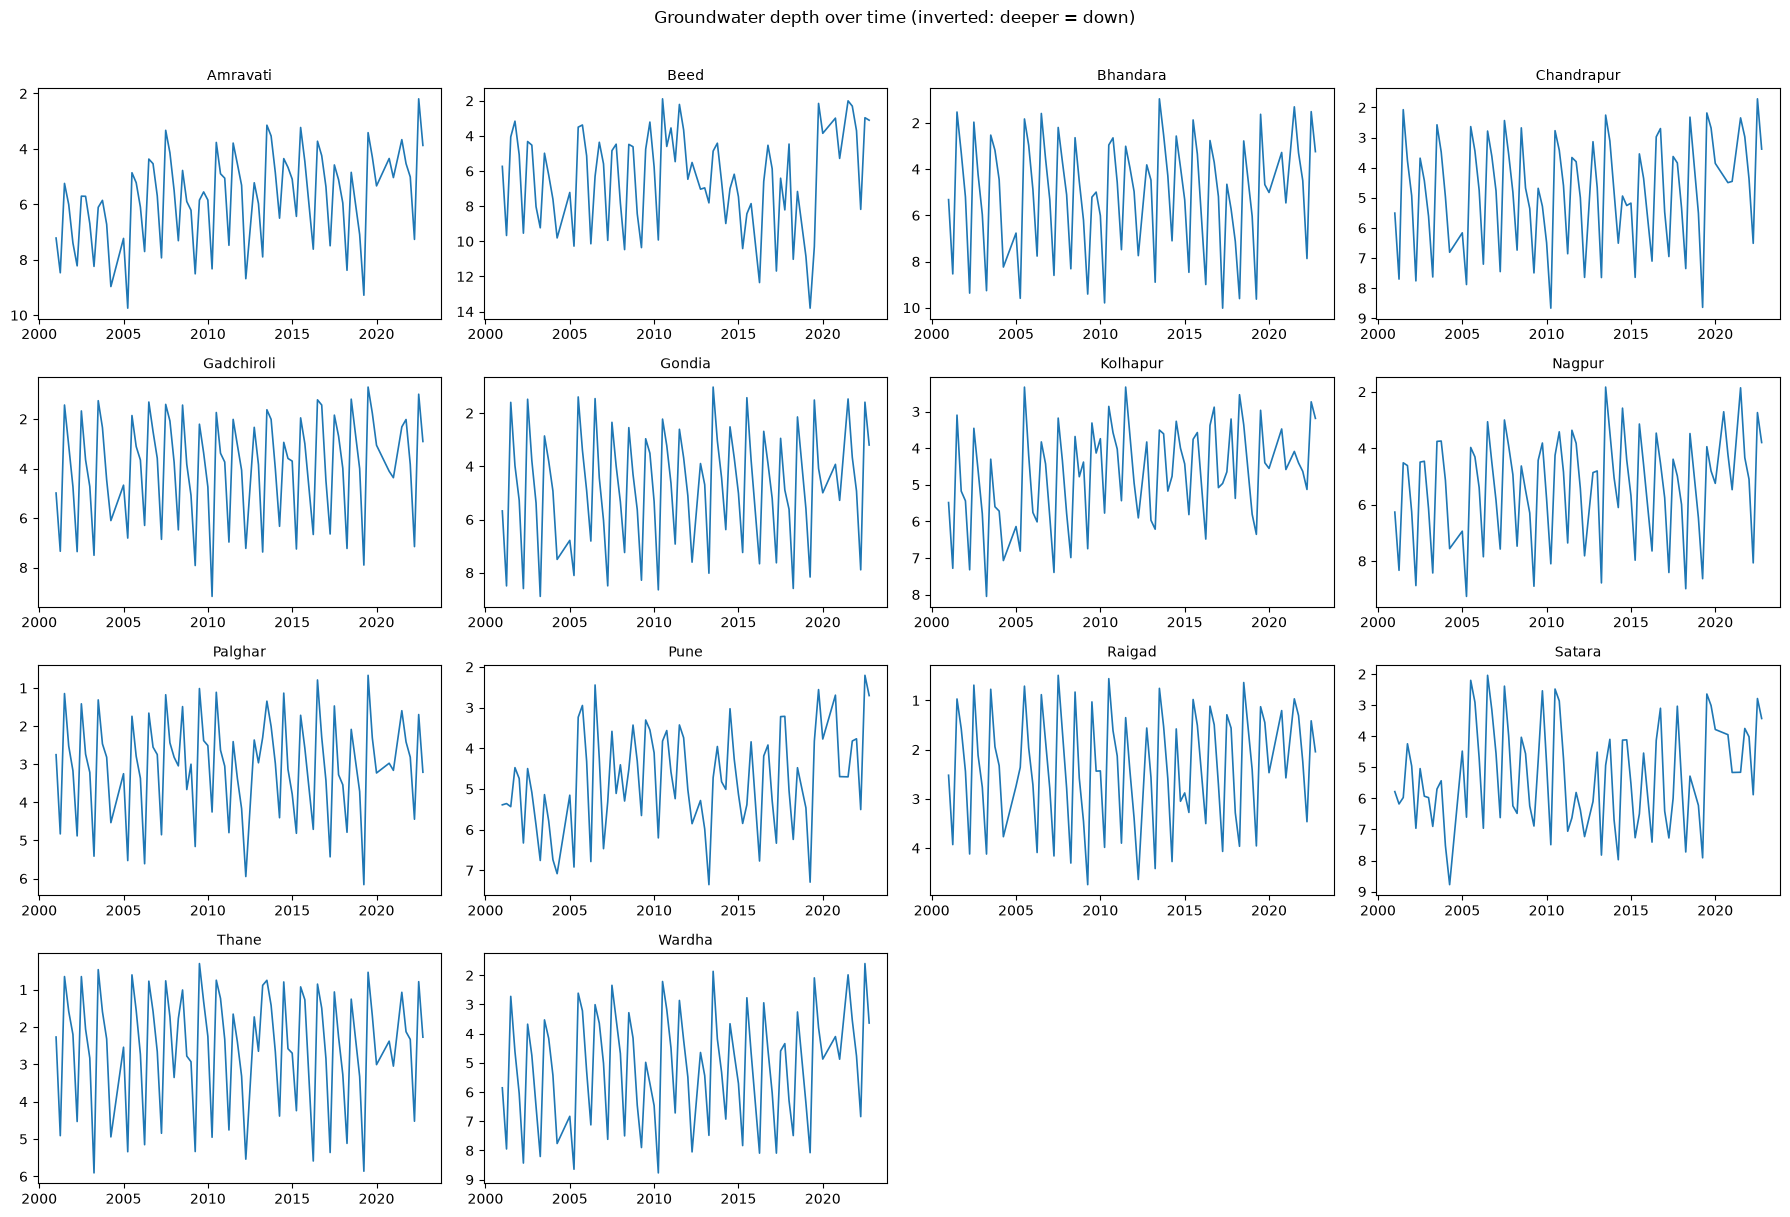

In [21]:
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()
districts = df['District'].unique()

for i, dist in enumerate(districts):
    sub = df[df['District'] == dist].sort_values(['Year','Quarter'])
    sub['time'] = sub['Year'] + (sub['Quarter'] - 1) / 4
    axes[i].plot(sub['time'], sub['GW_Depth_mbgl'], linewidth=1.2)
    axes[i].set_title(dist, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].invert_yaxis()  # deeper = lower on chart

# hide extra subplots if any
for j in range(len(districts), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Groundwater depth over time (inverted: deeper = down)', y=1.01)
plt.tight_layout()
plt.show()

Safe / Stable

Palghar & Raigad: Consistently shallow groundwater (1–6 mbgl) with strong annual monsoon recovery and no long-term decline. Lowest depletion risk.
Thane: Stable groundwater levels (1–6 mbgl) with reliable seasonal recharge, supported by coastal influence.

Moderate / Watchlist

Bhandara & Gondia: Groundwater varies between 2–9 mbgl with healthy seasonal recharge, though dry-season lows have deepened slightly since 2015.
Gadchiroli: Stable range (2–8 mbgl) with no significant long-term trend; remains relatively secure.
Nagpur: Seasonal cycle remains intact (2–9 mbgl), but recharge has stagnated, indicating limited long-term recovery.
Chandrapur: Similar to Nagpur, with slight groundwater deepening observed in recent years.

 Critical / High Risk

Amravati: Groundwater declined from ~5 mbgl to nearly 10 mbgl by 2010, followed by partial recovery. Overall stress remains high.
Beed: Most vulnerable district, reaching depths of 13–14 mbgl (2018–2019). Indicates severe groundwater stress and likely over-exploitation.
Wardha: Gradual long-term decline, with progressively deeper dry-season levels since 2015.

Notable Patterns

Kolhapur & Satara: Pronounced seasonal fluctuations (up to 8–9 mbgl) driven by Western Ghats rainfall, making rainfall a key predictive feature.
Pune: Stable groundwater (3–7 mbgl) until a noticeable decline during 2020–2022, suggesting increased extraction or urbanization impacts.
Raigad: Among the shallowest (1–4 mbgl) and most stable districts, benefiting from strong coastal recharge.

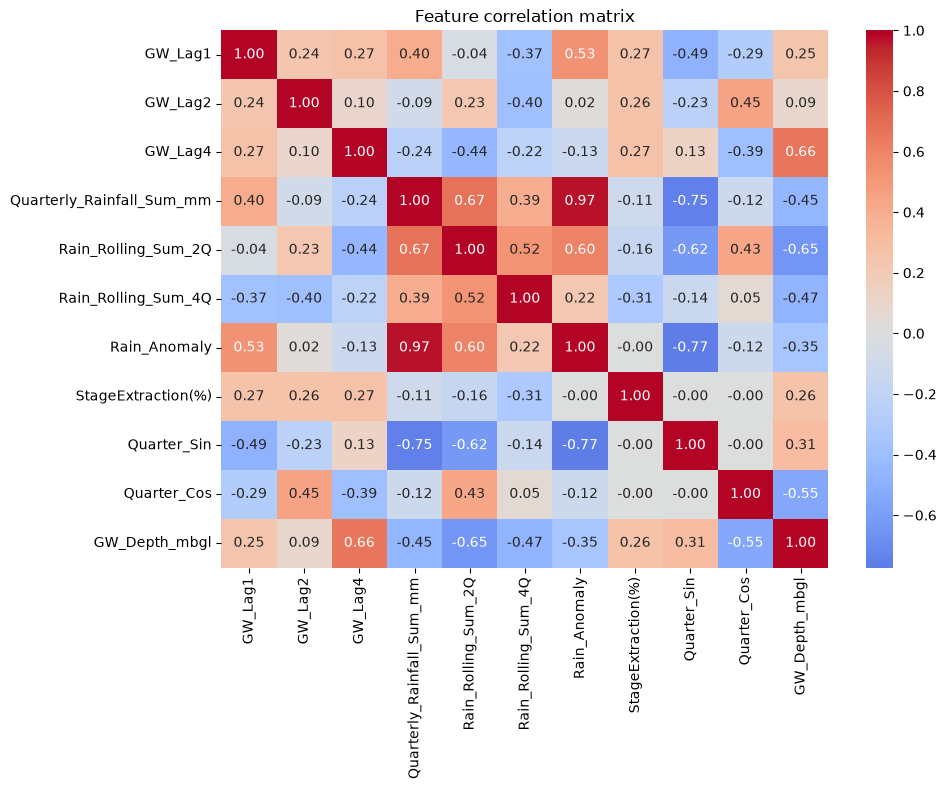

In [22]:
feature_cols = ['GW_Lag1','GW_Lag2','GW_Lag4',
                'Quarterly_Rainfall_Sum_mm',
                'Rain_Rolling_Sum_2Q',
                'Rain_Rolling_Sum_4Q',
                'Rain_Anomaly','StageExtraction(%)',
                'Quarter_Sin','Quarter_Cos']

corr = df[feature_cols + ['GW_Depth_mbgl']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [23]:
FEATURE_COLS = [
    'GW_Lag1', 'GW_Lag2', 'GW_Lag4',
    'Quarterly_Rainfall_Sum_mm',
    'Rain_Rolling_Sum_2Q', 'Rain_Rolling_Sum_4Q',
    'Rain_Anomaly', 'StageExtraction(%)',
    'Quarter_Sin', 'Quarter_Cos'
]
TARGET = 'GW_Depth_mbgl'

HOLDOUT_YEARS = [2021, 2022]

Important Features
Historical groundwater conditions
(GW_Lag4),

Recent rainfall and recharge
(Rain_Rolling_Sum_2Q)

Seasonal timing (Quarter_Cos/Quarter_Sin).

In [24]:
# Compare multiple models per district

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

MODELS = {
    'Random Forest':    RandomForestRegressor(n_estimators=500, max_depth=8, random_state=42),
    'Gradient Boost':   GradientBoostingRegressor(n_estimators=500, max_depth=4, random_state=42),
    'Ridge':            Ridge(alpha=1.0),
    'SVR':              SVR(kernel='rbf', C=10, epsilon=0.1)
}

comparison_results = []

for district in df['District'].unique():
    sub   = df[df['District'] == district]
    train = sub[~sub['Year'].isin(HOLDOUT_YEARS)]
    test  = sub[ sub['Year'].isin(HOLDOUT_YEARS)]

    X_train = train[FEATURE_COLS]
    y_train = train[TARGET]
    X_test  = test[FEATURE_COLS]
    y_test  = test[TARGET]

    for model_name, model in MODELS.items():
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model',  model)
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        comparison_results.append({
            'District':   district,
            'Model':      model_name,
            'MAE':        round(mean_absolute_error(y_test, y_pred), 3),
            'RMSE':       round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
            'R2':         round(r2_score(y_test, y_pred), 3),
        })

comp_df = pd.DataFrame(comparison_results)


print("=== Model Comparison Across All Districts ===\n")
print(comp_df.to_string(index=False))

=== Model Comparison Across All Districts ===

  District          Model   MAE  RMSE     R2
  Amravati  Random Forest 0.471 0.667  0.787
  Amravati Gradient Boost 0.354 0.561  0.849
  Amravati          Ridge 0.484 0.591  0.832
  Amravati            SVR 0.595 0.788  0.702
      Beed  Random Forest 1.328 1.384  0.520
      Beed Gradient Boost 0.991 1.111  0.691
      Beed          Ridge 0.767 0.868  0.811
      Beed            SVR 2.098 2.229 -0.246
  Bhandara  Random Forest 0.501 0.671  0.901
  Bhandara Gradient Boost 0.556 0.730  0.883
  Bhandara          Ridge 0.769 0.814  0.854
  Bhandara            SVR 1.134 1.277  0.641
Chandrapur  Random Forest 0.884 1.038  0.508
Chandrapur Gradient Boost 1.002 1.189  0.355
Chandrapur          Ridge 0.616 0.761  0.735
Chandrapur            SVR 1.237 1.404  0.100
Gadchiroli  Random Forest 0.477 0.616  0.891
Gadchiroli Gradient Boost 0.634 0.822  0.805
Gadchiroli          Ridge 0.735 0.800  0.816
Gadchiroli            SVR 0.735 0.826  0.803
    Gond

In [25]:
#  Show best model per district

# Find best model per district (lowest RMSE)
best_per_district = comp_df.loc[comp_df.groupby('District')['RMSE'].idxmin()]
print("\n=== Best Model Per District (by RMSE) ===\n")
print(best_per_district[['District', 'Model', 'RMSE', 'MAE', 'R2']].to_string(index=False))

# Count how many times each model wins
print("\n=== Overall Winner Count ===\n")
print(best_per_district['Model'].value_counts())


=== Best Model Per District (by RMSE) ===

  District          Model  RMSE   MAE    R2
  Amravati Gradient Boost 0.561 0.354 0.849
      Beed          Ridge 0.868 0.767 0.811
  Bhandara  Random Forest 0.671 0.501 0.901
Chandrapur          Ridge 0.761 0.616 0.735
Gadchiroli  Random Forest 0.616 0.477 0.891
    Gondia  Random Forest 0.497 0.342 0.944
  Kolhapur  Random Forest 0.712 0.615 0.188
    Nagpur  Random Forest 0.520 0.355 0.923
   Palghar            SVR 0.340 0.320 0.861
      Pune            SVR 0.756 0.595 0.511
    Raigad          Ridge 0.302 0.256 0.855
    Satara  Random Forest 0.976 0.774 0.103
     Thane  Random Forest 0.425 0.352 0.865
    Wardha  Random Forest 0.803 0.659 0.769

=== Overall Winner Count ===

Model
Random Forest     8
Ridge             3
SVR               2
Gradient Boost    1
Name: count, dtype: int64


Why using RANDOM FOREST explained above----

2000 to 2020 - Train Data

2021 - 2022  - Test Data

Next 3 months - Prediction

**MAE** - Calculate the avg prediction error

**RMSE** -  measures prediction error but penalizes large mistakes more heavily

**R²**- measures how well the model explains the variation in groundwater depth.Higher R² is better.

In [26]:


trained_models = {}
results        = []

for district in df['District'].unique():
    sub   = df[df['District'] == district]
    train = sub[~sub['Year'].isin(HOLDOUT_YEARS)]
    test  = sub[ sub['Year'].isin(HOLDOUT_YEARS)]

    X_train = train[FEATURE_COLS]
    y_train = train[TARGET]
    X_test  = test[FEATURE_COLS]
    y_test  = test[TARGET]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestRegressor(
            n_estimators=700,
            max_depth=15,        # reduced from 8 to avoid overfitting
            min_samples_leaf=2, # forces model to not overfit small patterns
            random_state=42
        ))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    trained_models[district] = pipe
    results.append({
        'District':   district,
        'MAE':        round(mae, 3),
        'RMSE':       round(rmse, 3),
        'R2':         round(r2, 3),
        'Train_rows': len(train),
        'Test_rows':  len(test)
    })

results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n=== Trained Model Performance ===\n")
print(results_df.to_string(index=False))


=== Trained Model Performance ===

  District   MAE  RMSE    R2  Train_rows  Test_rows
    Raigad 0.252 0.284 0.872          73          7
   Palghar 0.316 0.364 0.841          73          7
     Thane 0.361 0.428 0.863          73          7
    Gondia 0.362 0.508 0.941          73          7
    Nagpur 0.396 0.515 0.925          74          7
Gadchiroli 0.462 0.587 0.901          73          7
  Amravati 0.463 0.665 0.788          73          7
  Bhandara 0.511 0.697 0.893          73          7
  Kolhapur 0.616 0.721 0.168          73          7
    Wardha 0.659 0.811 0.764          73          7
      Pune 0.810 0.918 0.278          74          7
    Satara 0.783 0.964 0.125          73          7
Chandrapur 0.918 1.072 0.476          73          7
      Beed 1.480 1.546 0.401          73          7


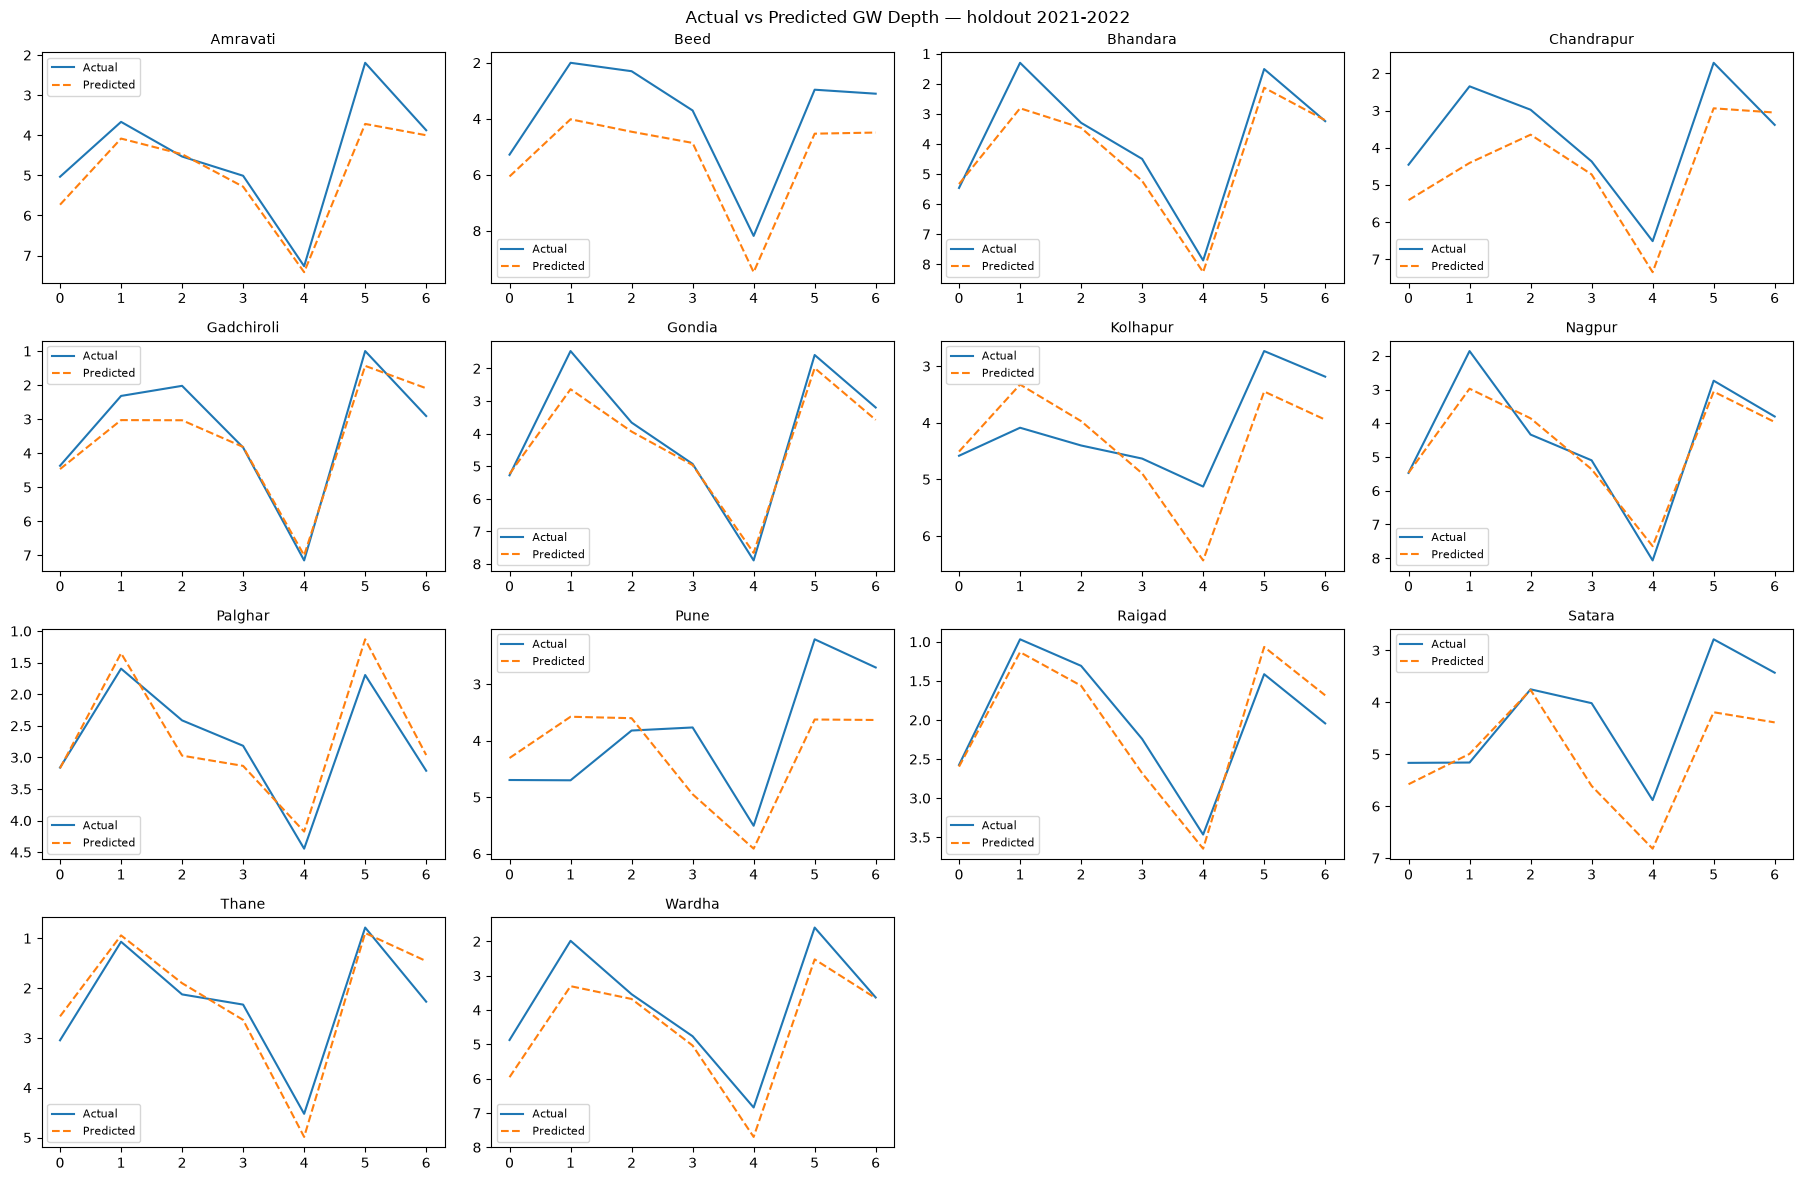

In [27]:
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

for i, district in enumerate(df['District'].unique()):
    sub   = df[df['District'] == district]
    test  = sub[sub['Year'].isin(HOLDOUT_YEARS)]
    pipe  = trained_models[district]

    y_pred = pipe.predict(test[FEATURE_COLS])
    y_true = test[TARGET].values

    axes[i].plot(y_true,  label='Actual',    linewidth=1.5)
    axes[i].plot(y_pred,  label='Predicted', linewidth=1.5, linestyle='--')
    axes[i].set_title(district, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].invert_yaxis()

for j in range(len(df['District'].unique()), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Actual vs Predicted GW Depth — holdout 2021-2022')
plt.tight_layout()
plt.show()

Problem in BEED KOHLAPUR CHANDRAPUR PUNE

In [28]:
import numpy as np
import pandas as pd

# Step 1: Precompute historical mean and std of rainfall per district per quarter
rain_mean = df.groupby(['District', 'Quarter'])['Quarterly_Rainfall_Sum_mm'].mean()
rain_std  = df.groupby(['District', 'Quarter'])['Quarterly_Rainfall_Sum_mm'].std()

def forecast_next_quarters(df, district, pipe, n=3):
    """Iteratively predict the next n quarters using last known data."""
    sub  = df[df['District'] == district].sort_values(['Year', 'Quarter'])
    last = sub.iloc[-1].copy()

    preds = []
    for q_ahead in range(1, n + 1):

        # Step 2: Calculate next quarter and year
        next_quarter = (last['Quarter'] % 4) + 1
        next_year    = last['Year'] + (1 if next_quarter == 1 else 0)
        q_rad        = next_quarter * (2 * np.pi / 4)

        # Step 3: Get historical mean and std for next quarter
        expected_rain = rain_mean.loc[(district, next_quarter)]
        std_rain      = rain_std.loc[(district, next_quarter)]

        # Step 4: Compute Z-Score anomaly
        if std_rain == 0:
            rain_anomaly = 0  # avoid division by zero if std is 0
        else:
            rain_anomaly = (last['Quarterly_Rainfall_Sum_mm'] - expected_rain) / std_rain

        # Step 5: Build feature row
        row = {
            'GW_Lag1':                   last['GW_Depth_mbgl'],
            'GW_Lag2':                   last['GW_Lag1'],
            'GW_Lag4':                   last['GW_Lag2'],
            'Quarterly_Rainfall_Sum_mm': expected_rain,
            'Rain_Rolling_Sum_2Q':       (last['Quarterly_Rainfall_Sum_mm'] + expected_rain) / 2,
            'Rain_Rolling_Sum_4Q':       last['Rain_Rolling_Sum_4Q'],
            'Rain_Anomaly':              rain_anomaly,
            'StageExtraction(%)':        last['StageExtraction(%)'],
            'Quarter_Sin':               np.sin(q_rad),
            'Quarter_Cos':               np.cos(q_rad),
        }

        # Step 6: Predict groundwater depth
        pred_depth = pipe.predict(pd.DataFrame([row]))[0]
        preds.append({
            'District':                district,
            'Year':                    next_year,
            'Quarter':                 next_quarter,
            'Predicted_GW_Depth_mbgl': round(pred_depth, 3)
        })

        # Step 7: Update last for next iteration
        last = last.copy()
        last['Quarter']                   = next_quarter
        last['Year']                      = next_year
        last['GW_Depth_mbgl']             = pred_depth
        last['GW_Lag1']                   = row['GW_Lag1']
        last['GW_Lag2']                   = row['GW_Lag2']
        last['Quarterly_Rainfall_Sum_mm'] = expected_rain  # update for next anomaly calculation

    return preds

# Step 8: Run for all districts
all_forecasts = []
for district in df['District'].unique():
    preds = forecast_next_quarters(df, district, trained_models[district], n=3)
    all_forecasts.extend(preds)

forecast_df = pd.DataFrame(all_forecasts)
print(forecast_df)

      District  Year  Quarter  Predicted_GW_Depth_mbgl
0     Amravati  2023        1                    5.249
1     Amravati  2023        2                    7.347
2     Amravati  2023        3                    4.728
3         Beed  2023        1                    5.360
4         Beed  2023        2                    9.466
5         Beed  2023        3                    5.298
6     Bhandara  2023        1                    4.561
7     Bhandara  2023        2                    8.231
8     Bhandara  2023        3                    2.773
9   Chandrapur  2023        1                    4.597
10  Chandrapur  2023        2                    7.060
11  Chandrapur  2023        3                    4.060
12  Gadchiroli  2023        1                    3.842
13  Gadchiroli  2023        2                    7.048
14  Gadchiroli  2023        3                    2.624
15      Gondia  2023        1                    4.514
16      Gondia  2023        2                    7.210
17      Go

In [29]:
# -------------------------------
# AI Risk based on Predicted Groundwater Depth
# -------------------------------
def assign_ai_risk(depth_mbgl):
    if depth_mbgl < 5:
        return "Safe"
    elif depth_mbgl < 10:
        return "Semi-Critical"
    elif depth_mbgl < 15:
        return "Critical"
    else:
        return "Over-Exploited"


# -------------------------------
# Government Risk based on Stage of Extraction
# -------------------------------
def govt_category(stage):
    if stage <= 70:
        return "Safe"
    elif stage <= 90:
        return "Semi-Critical"
    elif stage <= 100:
        return "Critical"
    else:
        return "Over-Exploited"


# AI Risk Label
forecast_df["AI_Risk_Label"] = forecast_df["Predicted_GW_Depth_mbgl"].apply(assign_ai_risk)


# Get latest Stage Extraction (%) for each district
latest_extraction = (
    df.sort_values(["District", "Year", "Quarter"])
      .groupby("District")["StageExtraction(%)"]
      .last()
      .reset_index()
)

# Merge with forecast dataframe
forecast_df = forecast_df.merge(
    latest_extraction,
    on="District",
    how="left"
)

# Government Risk Label
forecast_df["Government_Risk_Label"] = (
    forecast_df["StageExtraction(%)"]
    .apply(govt_category)
)

# Summary (latest forecast per district)
summary = (
    forecast_df
    .sort_values(["District", "Year", "Quarter"])
    .groupby("District")
    .last()
    .reset_index()
)

print("\n========== District Groundwater Risk Summary ==========\n")

print(summary[
    [
        "District",
        "Year",
        "Quarter",
        "Predicted_GW_Depth_mbgl",
        "AI_Risk_Label",
        "Government_Risk_Label"
    ]
].to_string(index=False))


========== District Groundwater Risk Summary ==========

  District  Year  Quarter  Predicted_GW_Depth_mbgl AI_Risk_Label Government_Risk_Label
  Amravati  2023        3                    4.728          Safe                  Safe
      Beed  2023        3                    5.298 Semi-Critical         Semi-Critical
  Bhandara  2023        3                    2.773          Safe                  Safe
Chandrapur  2023        3                    4.060          Safe                  Safe
Gadchiroli  2023        3                    2.624          Safe                  Safe
    Gondia  2023        3                    3.403          Safe                  Safe
  Kolhapur  2023        3                    4.013          Safe                  Safe
    Nagpur  2023        3                    4.285          Safe                  Safe
   Palghar  2023        3                    1.669          Safe                  Safe
      Pune  2023        3                    5.629 Semi-Critical        

Government risk level on the basis of stage extraction provided by RAJ

In [30]:
# Verify risk thresholds are correct for YOUR data

print("=== Actual GW Depth statistics per district ===\n")

stats = df.groupby('District')['GW_Depth_mbgl'].agg(['min','max','mean','std']).round(2)
print(stats)

print("\n=== Current risk thresholds ===")
print("  Safe           : depth < 5 mbgl")
print("  Semi-Critical  : 5 – 10 mbgl")
print("  Critical       : 10 – 15 mbgl")
print("  Over-Exploited : depth > 15 mbgl")

print("\n=== How many rows fall in each risk category (actual data) ===\n")
def assign_risk(depth_mbgl):
    if depth_mbgl < 5:
        return 'Safe'
    elif depth_mbgl < 10:
        return 'Semi-Critical'
    elif depth_mbgl < 15:
        return 'Critical'
    else:
        return 'Over-Exploited'

df['Risk_Actual'] = df['GW_Depth_mbgl'].apply(assign_risk)
risk_counts = df.groupby(['District','Risk_Actual']).size().unstack(fill_value=0)
print(risk_counts)

=== Actual GW Depth statistics per district ===

             min    max  mean   std
District                           
Amravati    2.19   9.75  5.78  1.67
Beed        1.89  13.81  6.43  2.77
Bhandara    0.96  10.02  5.09  2.52
Chandrapur  1.71   8.67  4.83  1.83
Gadchiroli  0.71   9.16  3.97  2.13
Gondia      1.02   8.89  4.78  2.20
Kolhapur    2.33   8.05  4.71  1.34
Nagpur      1.83   9.25  5.39  1.88
Palghar     0.67   6.16  3.04  1.33
Pune        2.21   7.35  4.75  1.25
Raigad      0.49   4.74  2.38  1.18
Satara      2.04   8.78  5.26  1.64
Thane       0.30   5.91  2.55  1.58
Wardha      1.60   8.77  5.16  1.92

=== Current risk thresholds ===
  Safe           : depth < 5 mbgl
  Semi-Critical  : 5 – 10 mbgl
  Critical       : 10 – 15 mbgl
  Over-Exploited : depth > 15 mbgl

=== How many rows fall in each risk category (actual data) ===

Risk_Actual  Critical  Safe  Semi-Critical
District                                  
Amravati            0    28             52
Beed            

In [31]:
import joblib

# Save trained models
joblib.dump(trained_models, "../models/trained_models.pkl")

# Save feature information
feature_info = {
    "FEATURE_COLS": FEATURE_COLS,
    "TARGET": TARGET,
    "HOLDOUT_YEARS": HOLDOUT_YEARS
}

joblib.dump(feature_info, "../models/feature_info.pkl")

# Save forecast data
forecast_df.to_csv("../data/forecast_2023.csv", index=False)

print("✅ All files saved successfully!")

✅ All files saved successfully!


In [ ]:
print(FEATURE_COLS)
print(len(FEATURE_COLS))

['GW_Lag1', 'GW_Lag2', 'GW_Lag4', 'Quarterly_Rainfall_Sum_mm', 'Rain_Rolling_Sum_2Q', 'Rain_Rolling_Sum_4Q', 'Rain_Anomaly', 'StageExtraction(%)', 'Quarter_Sin', 'Quarter_Cos']
10


: 